In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rc('font',   size=12)          # controls default text sizes
plt.rc('axes',   titlesize=14)     # fontsize of the axes title
plt.rc('axes',   labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=14)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=14)     # fontsize of the tick labels
plt.rc('legend', fontsize=14)      # legend fontsize
plt.rc('figure', titlesize=14)     # fontsize of the figure title
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["mathtext.fontset"] = "cm"

In [2]:
import astropy
print(astropy.__version__)

7.2.0


/var/folders/l_/95r5zgdx7n57rjhvrqktjj_w0000gn/T/ipykernel_7593/893127168.py:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(labels1)
/var/folders/l_/95r5zgdx7n57rjhvrqktjj_w0000gn/T/ipykernel_7593/893127168.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax11.set_yticklabels(labels2)


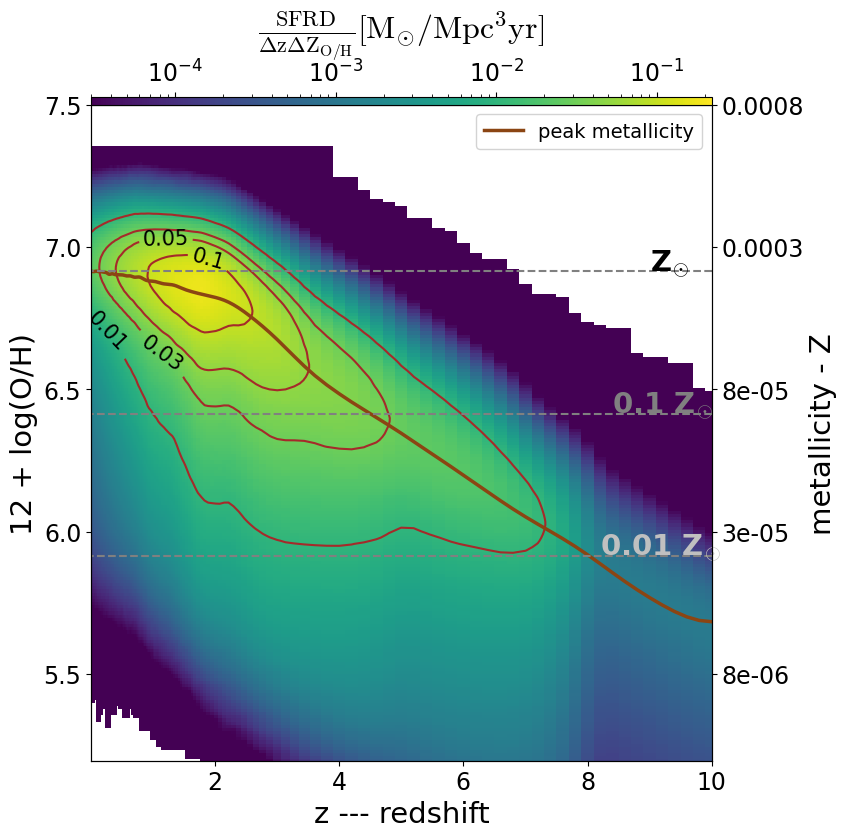

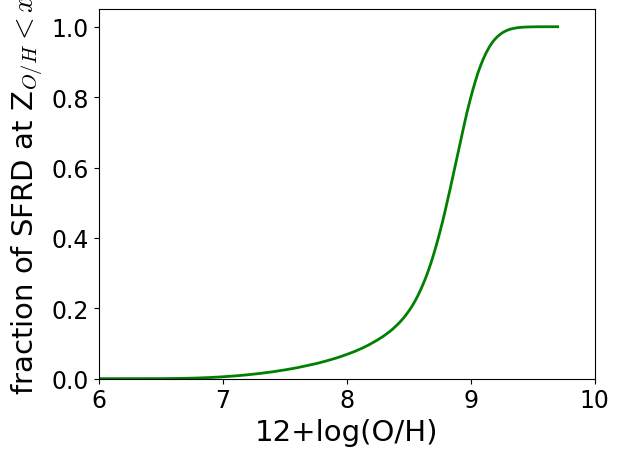

In [50]:
''' 
# online material accompanying the paper: Chruslinska, M. & Nelemans, G., MNRAS, 2019 (DOI: 10.1093/mnras/stz2057)
# this python script allows to visualize the data (plot the SFRD(Z,z) distribution and CDF at a given redshift)
# usage: python plot_SFRD_Z_z.py
# adjust the data input file name (input_file); see example use at the bottom
# need 'Time_redshift_deltaT.dat' and input file with the data for a chosen variation (any of the '*FOH_z_dM.dat')
'''

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import matplotlib.colors as colors

labelsize=21
ticklabsize=17

def solar_metallicity_scales():
    Asplund09=[0.0134,8.69]
    AndersGrevesse89=[0.017,8.83]
    GrevesseSauval98=[0.0201,8.93]
    Villante14=[0.019,8.85]
    scale_ref=np.array(['Asplund09','AndersGrevesse89','GrevesseSauval98','Villante14'])
    Z_FOH_solar=np.array([Asplund09,AndersGrevesse89,GrevesseSauval98,Villante14])
    return scale_ref, Z_FOH_solar

def FOH2ZZ(foh,solar_Z_scale='AndersGrevesse89'):
    '''convert from 12+log[O/H] to ZZ'''
    scale_ref, Z_FOH_solar=solar_metallicity_scales()
    idx=np.where(scale_ref==solar_Z_scale)[0][0]
    Zsun,FOHsun = Z_FOH_solar[idx]    
    logZ = np.log10(Zsun) + foh - FOHsun
    ZZ=10**logZ
    return ZZ

def ZZ2FOH(zz,solar_Z_scale='AndersGrevesse89'):
    '''convert from ZZ to 12+log[O/H] '''
    scale_ref, Z_FOH_solar=solar_metallicity_scales()
    idx=np.where(scale_ref==solar_Z_scale)[0][0]
    Zsun,FOHsun = Z_FOH_solar[idx]
    foh = np.log10(zz)-np.log10(Zsun)+FOHsun
    return foh

def smooth(d, c=2):
    if c == 0:
        return d
    x = np.zeros(len(d))
    x[0] = (d[1]+d[0])/2
    x[-1] = (d[-1]+d[-2])/2
    x[1:-1] = (2*d[1:-1]+d[:-2]+d[2:])/4
    return smooth(x, c=c-1)

#(array) oxygen to hydrogen abundance ratio ( FOH == 12 + log(O/H) )
# as used in the calculations - do not change
FOH_min, FOH_max = 5.3, 9.7
FOH_arr = np.linspace( FOH_min,FOH_max, 200)
dFOH=FOH_arr[1]-FOH_arr[0]

def get_plot_data(input_file,zmin=0.,zmax=4):

    #read time, redshift and timestep as used in the calculations
    #starts at the highest redshift (z=z_start=10) and goes to z=0
    time, redshift_global, delt = np.loadtxt('Time_redshift_deltaT.dat',unpack=True) 
    #reading mass per unit (comoving) volume formed in each z (row) - FOH (column) bin
    data=np.loadtxt(input_file)
    image_data=np.array( [data[ii]/(1e6*delt[ii]) for ii in range(len(delt))] )#fill the array with SFRD(FOH,z)

    redshift=redshift_global
    #select the interesting redshift range
    if( zmax!=10 or zmin!=0 ):
        idx= np.where(np.abs(np.array(redshift)-zmax)==np.abs(np.array(redshift)-zmax).min())[0][0] 
        idx0= np.where(np.abs(np.array(redshift)-zmin)==np.abs(np.array(redshift)-zmin).min())[0][0] 
        image_data = image_data[idx:idx0]
        redshift=redshift_global[idx:idx0]
        delt=delt[idx:idx0]

    image_data/=dFOH
    return image_data, redshift, delt

def plot_data_single_panel(input_file, zmin=0.,zmax=10,solar_Z_scale='AndersGrevesse89'):

    #read data
    image,redshift,delt = get_plot_data(input_file,zmin,zmax)

    scale_ref, Z_FOH_solar=solar_metallicity_scales()
    idx=np.where(scale_ref==solar_Z_scale)[0][0]
    Zsun,FOHsun = Z_FOH_solar[idx]
    FOHymin,FOHymax=5.39,10.
  
    fig1=plt.figure(figsize=(8.5,6))
    ax1 = plt.subplot2grid((3, 1), (0, 0), colspan=1, rowspan=3)
    ax11 = ax1.twinx()

    #plotting
    vmin=3e-5
    vmax=0.22
    idx_peak_SFRH = np.where( np.abs(np.array(redshift)-1.8)==np.min(np.abs(np.array(redshift)-1.8)) )[0][0]
    c='saddlebrown'
    image1 = ndimage.gaussian_filter(image,1,0)
    pcm=ax1.pcolormesh(redshift, FOH_arr, np.transpose(image1),norm=colors.LogNorm(vmin=vmin, vmax=vmax ))#,cmap='OrRd' )
    levels=[0.01,0.03,0.05,0.1]
    CS=ax1.contour(redshift,FOH_arr, np.transpose(image1),levels=levels,colors=('brown',),linestyles=('-',),linewidths=(1.5,))
    ax1.clabel(CS, fmt = '%g', colors ='k', fontsize=15) #contour line labels
    SFRD_atz_Z = np.array([image1[:][ii] for ii in range(len(image1[:,0]))])
    maxima = np.array([SFRDi[2:].max() for SFRDi in SFRD_atz_Z ])
    indices=[np.where( np.abs(maxi-SFRDi[2:])==np.min(np.abs(maxi-SFRDi[2:])))[0][-1] for maxi,SFRDi in zip(maxima,SFRD_atz_Z)]
    FOHmax=np.array(FOH_arr[indices])+(FOH_arr[1]-FOH_arr[0])*0.5
    ax1.plot(redshift,smooth(np.array(FOHmax),10),lw=2.5,c=c,label='peak metallicity')

    #prepare labels for y-axes
    fig1.canvas.draw()
    labels = [item.get_text() for item in ax1.get_yticklabels()]
    labels2=[]
    for l in labels[:]:
            #print l
            if l=='': labels2.append('')
            else: 
                 labels2.append( str('%.1g'%(FOH2ZZ(float(l),solar_Z_scale))) )
    labels1=[]
    labels1.append('')
    labels1+=labels[1:]
    ax1.set_yticklabels(labels1)
    ax11.set_yticklabels(labels2)

    #add legend
    lgnd = ax1.legend( loc='upper right', prop={'size':int(14)},\
            fancybox=True,numpoints=1,scatterpoints = 1)#,frameon=False)
    frame = lgnd.get_frame()
    frame.set_alpha(0.85)

    #adjust size
    w,h=fig1.get_size_inches()
    fig1.set_size_inches(w,h+2.2, forward=True)
    ttop,lleft,rright,bbottom=0.88,0.12,0.85,0.08
    plt.subplots_adjust(left=lleft, bottom=bbottom, right=rright, top=ttop, wspace=0.01, hspace=0.0)

    #add colorbar
    cbaxes = fig1.add_axes([lleft, ttop, rright-lleft, 0.01])
    cb=plt.colorbar(pcm, orientation='horizontal', cax=cbaxes)
    cb.set_label(label=r'$\rm \frac{SFRD}{\Delta z \Delta Z_{O/H}} [M_{\odot}/Mpc^{3}yr]$',\
                size=labelsize+2, labelpad=15)
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('top')
    cb.ax.tick_params(labelsize=ticklabsize)

    #add description    
    ax1.tick_params(
            axis='both',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            top=False, #top ticks off
            labelbottom=True,
            labeltop=False,
            labelleft=True,
            labelright=False,
            labelsize=ticklabsize) # labels along the bottom edge are off
    ax11.tick_params(
            axis='both',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            top=False,
            labelbottom=False,
            labeltop=False,
            labelleft=False,
            labelright=True,
            labelsize=ticklabsize) # labels along the bottom edge are off

    ax1.set_xlabel('redshift')
    ax1.set_ylim([FOHymin,FOHymax])
    ax11.set_ylim([FOHymin,FOHymax])
    ax11.set_ylabel('metallicity - Z',fontsize=labelsize )
    ax1.set_ylabel('12 + log(O/H)',fontsize=labelsize )
    ax1.set_xlim([min(redshift), max(redshift)])
    ax1.set_xlabel('z --- redshift', fontsize=labelsize)

    cann,cann2='gray','gray'
    ax1.plot( redshift, [FOHsun for z in redshift], ls='--', c=cann2,lw=1.5)
    ax1.annotate(r'Z$_{\odot}$', xy=(redshift[5],ZZ2FOH(Zsun,solar_Z_scale)+0.0005),\
     xycoords='data',fontsize=labelsize, fontweight='bold',color='k')
    ax1.plot( redshift, [ZZ2FOH(0.1*Zsun,solar_Z_scale) for z in redshift], ls='--', c=cann2,lw=1.5)
    ax1.annotate(r'0.1 Z$_{\odot}$', xy=(redshift[8],ZZ2FOH(0.1*Zsun,solar_Z_scale)+0.0005),\
     xycoords='data',fontsize=labelsize, fontweight='bold',color=cann)
    cann,cann2='silver','gray'
    ax1.plot( redshift, [ZZ2FOH(0.01*Zsun,solar_Z_scale) for z in redshift], ls='--', c=cann2,lw=1.5)
    ax1.annotate(r'0.01 Z$_{\odot}$', xy=(redshift[9],ZZ2FOH(0.01*Zsun,solar_Z_scale)+0.00005),\
     xycoords='data',fontsize=labelsize, fontweight='bold',color=cann)

    plt.show()

def prepare_CDF(SFRD_data):

    #NORMALIZE the input data
    mtot_z = [np.sum(SFRD_data[:][ii]) for ii in range(SFRD_data.shape[0])]
    SFRD_normed = np.array([ [(SFRD_data[ii][j])/mtot_z[ii] for\
                     j in range(SFRD_data.shape[1])] for ii in range(SFRD_data.shape[0])]) 
    #CALCULATE the cumulative sum of the data
    Z_cumsum = np.array([ [np.sum(SFRD_normed[ii][:j]) for j in range(SFRD_data.shape[1])]\
                             for ii in range(SFRD_data.shape[0])])
    Z_cumsum=np.transpose(Z_cumsum)
    return Z_cumsum

def plot_CDF(input_file, zzi=[0], color='g',label='' ):

    image,redshift,delt = get_plot_data(input_file,zmin=0,zmax=10)
    Z_cumsum=prepare_CDF(image)
    redshift=np.array(redshift)

    fig1=plt.figure(1)
    ax1 = fig1.add_subplot(111)
    ax1.tick_params(axis='x', which='major', labelsize=ticklabsize)
    ax1.tick_params(axis='y', which='major', labelsize=ticklabsize)
    ax1.set_ylabel('fraction of SFRD at Z$_{O/H}<x$',fontsize=labelsize)
    ax1.tick_params(axis='x', which='major', labelsize=ticklabsize)
    ax1.tick_params(axis='y', which='major', labelsize=ticklabsize)
    ax1.set_ylim([0.,1.05])
    ax1.set_xlim([6.,10])
    ax1.set_xlabel('12+log(O/H)',fontsize=labelsize)

    lw=2
    alpha=1
    colors = plt.cm.jet(np.linspace(0,1,len(zzi)))
    for z,c in zip(zzi,colors):
        iz=np.where( np.abs(redshift-z)==np.min( np.abs(redshift-z) ) )[0][0]
        frac_Z=Z_cumsum[:,iz] #CDF at z=zzi
        if(len(zzi)==1):
                ax1.plot(FOH_arr, frac_Z,c=color,ls='-',lw=lw,label=label+'; z='+str(z),alpha=alpha)
        else:
                ax1.plot(FOH_arr, frac_Z,c=c,ls='-',lw=lw,label='z='+str(z),alpha=alpha)
    return Z_cumsum

''' Example use: '''
''' plot the SFRD(Z,z) distribution (as e.g. in Fig. 6 from the paper) '''
# solar metallicity is shown in the figure to guide the eye; the conversion can be changed
# (see function solar_metallicity_scales() and keyword solar_Z_scale below)
input_file='moderate_FOH_z_dM.dat'
plot_data_single_panel(input_file, zmin=0.,zmax=10,solar_Z_scale='AndersGrevesse89')

''' example CDF plot comparing the high-Z extreme, moderate variation and low-Z extreme at redshift=zzi '''
# zzi=[0]
# input_file='high-Z_extreme_FOH_z_dM.dat'
# image,redshift,delt = get_plot_data(input_file,zmin=0,zmax=10)
# Z_cumsum = plot_CDF(input_file, zzi=zzi ,color='r',label='high-Z extreme' )

zzi=[0]
input_file='moderate_FOH_z_dM.dat'
image,redshift,delt = get_plot_data(input_file,zmin=0,zmax=10)
Z_cumsum = plot_CDF(input_file, zzi=zzi, label='moderate' )

# input_file='low-Z_extreme_FOH_z_dM.dat'
# image,redshift,delt = get_plot_data(input_file,zmin=0,zmax=10)
# Z_cumsum = plot_CDF(input_file, zzi=zzi, color='b',label='low-Z extreme' )

# plt.legend(loc='best',ncol=1)
# plt.tight_layout()
# plt.show()

In [ ]:
import jax.numpy as jnp
import jax
from typing import Dict, List

def get_solar_metallicity_data():
    """Returns a dictionary of solar metallicity scales: {name: [Z_sun, 12+log(O/H)]}"""
    scales: Dict[str, List[float]] = {
        'Asplund09':        [0.0134, 8.69],
        'AndersGrevesse89': [0.017,  8.83],
        'GrevesseSauval98': [0.0201, 8.93],
        'Villante14':       [0.019,  8.85]
    }
    return scales

def FOH2ZZ(foh, solar_Z_scale='AndersGrevesse89'):
    """Convert from 12+log[O/H] to Z (mass fraction)"""
    scales = get_solar_metallicity_data()
    
    if solar_Z_scale not in scales:
        raise ValueError(f"Scale '{solar_Z_scale}' not found. Choose from: {list(scales.keys())}")
    
    z_sun, foh_sun = scales[solar_Z_scale]
    
    # Calculate Z using the relation: log10(Z) = log10(Z_sun) + (12+log(O/H) - (12+log(O/H)_sun))
    log_z = np.log10(z_sun) + foh - foh_sun
    return 10**log_z

def ZZ2FOH(zz, solar_Z_scale='AndersGrevesse89'):
    scales=get_solar_metallicity_data()
    if solar_Z_scale not in scales:
        raise ValueError(f"Scale '{solar_Z_scale}' not found. Choose from: {list(scales.keys())}")
    
    z_sun, foh_sun = scales[solar_Z_scale]

    foh = np.log10(zz)-np.log10(z_sun)+foh_sun
    return foh

time, redshift_global, delt = jnp.asarray(np.loadtxt('Time_redshift_deltaT.dat',unpack=True))
data = jnp.asarray(np.loadtxt(input_file))
sfrd_bins = data / (1e6 * delt[:,None])
FOH_min, FOH_max = 5.3, 9.7
FOH_arr = jnp.linspace( FOH_min,FOH_max, 200)
dFOH=FOH_arr[1]-FOH_arr[0]

sfrd_cdf = jnp.zeros((len(redshift_global), 201))
sfrd_cdf = sfrd_cdf.at[:,1:].set(jnp.cumsum(sfrd_bins, axis=1))
FOH_cdf_x = jnp.insert(FOH_arr, 0, FOH_arr[0] - (FOH_arr[1] - FOH_arr[0]))

Z_vals = jnp.array([0.0001, 0.001, 0.005, 0.01, 0.02, 0.03])
Z_bins = jnp.array([FOH2ZZ(FOH_min), 0.0005, 0.003, 0.008, 0.015, 0.03, FOH2ZZ(FOH_max)])

FOH_bins = ZZ2FOH(Z_bins)
sfrd_z_Z = jnp.zeros((len(redshift_global), len(Z_vals)))

for i in range(len(Z_vals)):
    foh_low = FOH_bins[i]
    foh_high = FOH_bins[i+1]
    
    cdf_high = np.array([np.interp(foh_high, FOH_cdf_x, sfrd_cdf[z_idx]) for z_idx in range(len(redshift_global))])
    cdf_low = np.array([np.interp(foh_low, FOH_cdf_x, sfrd_cdf[z_idx]) for z_idx in range(len(redshift_global))])
    
    sfrd_mass = cdf_high - cdf_low
    
    sfrd_z_Z = sfrd_z_Z.at[:,i].set(sfrd_mass)
    
z_data = jnp.flip(redshift_global)
sfrd_z_Z = jnp.flip(sfrd_z_Z, axis=0)

z_idx = jnp.arange(len(z_data))
Z_idx = jnp.arange(len(Z_vals))

z_eval = jnp.flip(redshift.values)[:, None]
Z_eval = Z_vals[None,:]

z_frac_idx = jnp.interp(z_eval, z_data, z_idx)
Z_frac_idx = jnp.interp(Z_eval, Z_vals, Z_idx)

z_frac_idx, Z_frac_idx = jnp.broadcast_arrays(z_frac_idx, Z_frac_idx)

coords = jnp.stack([z_frac_idx, Z_frac_idx])

# Fast bilinear interpolation on the GPU/CPU
psi = jax.scipy.ndimage.map_coordinates(
    sfrd_z_Z, coords, order=1, mode='nearest'
)

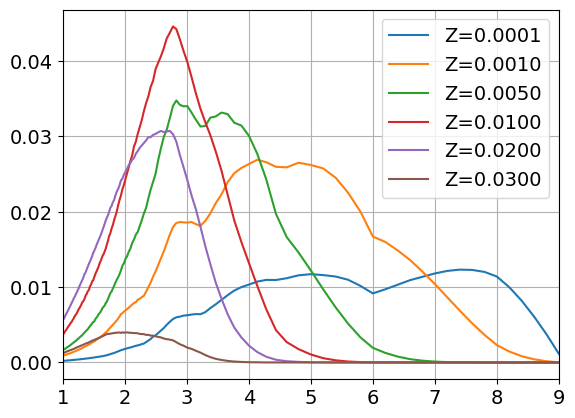

Array(0.13560635, dtype=float32)

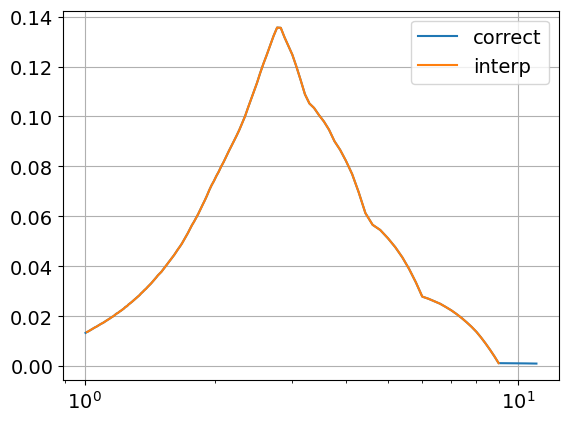

In [182]:
for Z_idx in range(sfrd_z_Z.shape[1]):
    # plt.loglog(1+redshift_global, sfrd_z_Z[:,Z_idx], label=f"Z={Z_vals[Z_idx]:.4f}")
    plt.plot(1+z_eval, psi[:,Z_idx], label=f"Z={Z_vals[Z_idx]:.4f}")
    
# plt.ylim([0.0002, 0.3])
plt.xlim([1,9])
plt.legend()
plt.grid()
plt.show()

plt.plot(1+jnp.flip(redshift_global), jnp.sum(sfrd_z_Z,axis=1), label='correct')
plt.plot(1+z_eval, jnp.sum(psi, axis=1), label='interp')
plt.xscale("log")
plt.grid()
plt.legend()
np.max(jnp.sum(sfrd_z_Z, axis=1))

In [128]:
redshift_global

Array([1.00000000e+01, 9.80000019e+00, 9.60000038e+00, 9.39999962e+00,
       9.19999981e+00, 9.00000000e+00, 8.80000019e+00, 8.60000038e+00,
       8.39999962e+00, 8.19999981e+00, 8.00000000e+00, 7.80000019e+00,
       7.59999990e+00, 7.40000010e+00, 7.19999981e+00, 7.00000000e+00,
       6.80000019e+00, 6.59999990e+00, 6.40000010e+00, 6.19999981e+00,
       6.00000000e+00, 5.80000019e+00, 5.59999990e+00, 5.40000010e+00,
       5.19999981e+00, 5.00000000e+00, 4.80000019e+00, 4.59999990e+00,
       4.40000010e+00, 4.19999981e+00, 4.00000000e+00, 3.79999995e+00,
       3.60974550e+00, 3.43706131e+00, 3.27947259e+00, 3.13495803e+00,
       3.00185132e+00, 2.87876439e+00, 2.76453137e+00, 2.65816498e+00,
       2.55882359e+00, 2.46578336e+00, 2.37841940e+00, 2.29619002e+00,
       2.21862125e+00, 2.14529657e+00, 2.07585073e+00, 2.00995827e+00,
       1.94733083e+00, 1.88771248e+00, 1.83087230e+00, 1.77660358e+00,
       1.72472072e+00, 1.67505479e+00, 1.62745535e+00, 1.58178282e+00,
      

In [6]:
plt.rc('font',   size=12)          # controls default text sizes
plt.rc('axes',   titlesize=14)     # fontsize of the axes title
plt.rc('axes',   labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=14)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=14)     # fontsize of the tick labels
plt.rc('legend', fontsize=14)      # legend fontsize
plt.rc('figure', titlesize=14)     # fontsize of the figure title
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["mathtext.fontset"] = "cm"

0.13560633


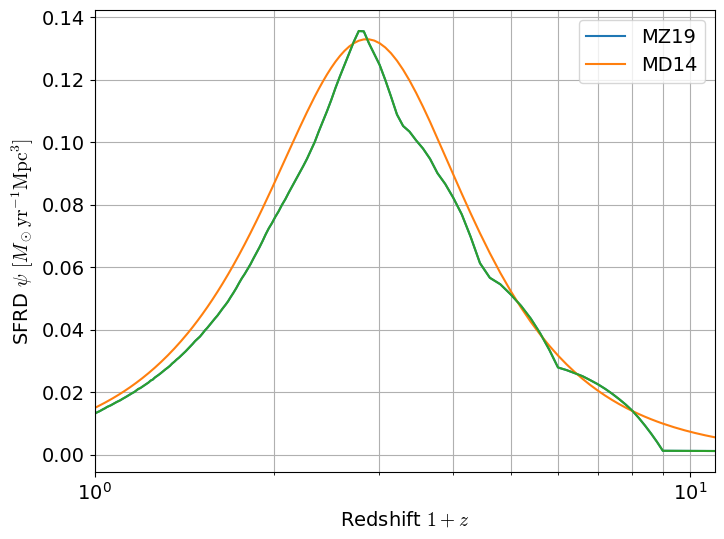

In [129]:
high = 'high-Z_extreme_FOH_z_dM.dat.txt'
low = 'low-Z_extreme_FOH_z_dM.dat.txt'
mod = 'moderate_FOH_z_dM.dat'
sb_low = '204f14SBBiC_FMR270_FOH_z_dM.dat'
sb_high = '302f14SBBiC_FMR270_FOH_z_dM.dat'
labels = ['MZ19']# , 'LZ19', 'HZ19', 'LZ21', 'HZ21']
SFRDs = [mod] #, low, high, sb_low, sb_high]
plt.figure(figsize=(8,6))
for i, input_file in enumerate(SFRDs):
    image,redshift,delt = get_plot_data(input_file,0.,10)
    SFRD_z = np.sum(image, axis=1)*dFOH
    plt.plot(1+redshift, SFRD_z, label=labels[i])
    print(np.max(SFRD_z))
    
def MnD(z):
    return 0.015 *(1+z)**2.7 / (1+((1+z)/2.9)**5.6)

plt.plot(1+redshift, MnD(redshift), label = 'MD14')    
plt.plot(1+redshift_global, jnp.sum(sfrd_z_Z,axis=1))

plt.xlim([1, 11])
plt.xscale('log')
# plt.yscale('log')
plt.grid(which='both')
plt.xlabel(r'Redshift $1+z$')
plt.ylabel(r'SFRD $\psi$ $[M_\odot \rm{yr}^{-1} \rm{Mpc}^3]$')
plt.legend()
plt.show()



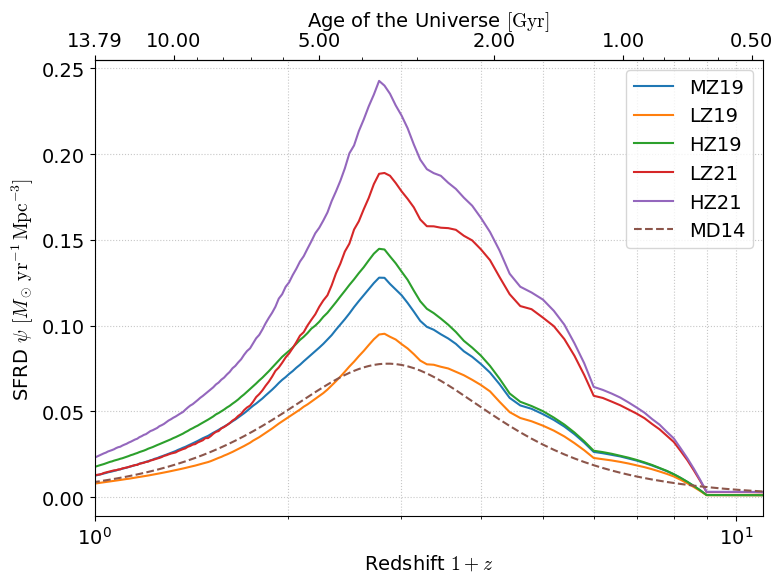

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo # Choose your cosmology
from astropy.cosmology.funcs import z_at_value
from astropy.cosmology.core import CosmologyError
import astropy.units as u

# --- Define cosmological conversion functions for 1+z and Age ---
IMF_conv = 1/1.06
def one_plus_z_to_age(one_plus_z_val):
    """Converts 1+z to age of the Universe in Gyr."""
    z_val = np.atleast_1d(one_plus_z_val) - 1.0
    # Ensure z is not negative (e.g., if 1+z < 1, which shouldn't happen here but good practice)
    z_val[z_val < 0] = 0
    ages = cosmo.age(z_val).to(u.Gyr).value
    return ages[0] if np.isscalar(one_plus_z_val) else ages

def age_to_one_plus_z(age_val_gyr):
    """
    Converts age of the Universe in Gyr back to 1+z.
    Handles scalar or array-like input for age_val_gyr by iterating.
    """
    age_values = np.atleast_1d(age_val_gyr)
    one_plus_z_results = np.empty_like(age_values, dtype=float)

    age_at_z0 = cosmo.age(0).to(u.Gyr).value

    zmin_search = 0.0
    zmax_search = 100.0 # Max redshift for search, needs to be high enough for young ages
                        # e.g., age at z=10 is ~0.47 Gyr. Age at z=100 is ~0.017 Gyr
    ztol_search = 1e-6

    for i, age_gyr in enumerate(age_values):
        if age_gyr <= 0:
            one_plus_z_results[i] = np.nan
        elif age_gyr >= age_at_z0 - 1e-9: # Comparing with age at z=0
            one_plus_z_results[i] = 1.0 # (corresponds to z=0)
        else:
            try:
                z_result = z_at_value(
                    cosmo.age,
                    age_gyr * u.Gyr,
                    zmin=zmin_search,
                    zmax=zmax_search,
                    ztol=ztol_search
                )
                one_plus_z_results[i] = 1.0 + z_result
            except CosmologyError:
                # print(f"Warning: CosmologyError for age {age_gyr} Gyr. Youngest age at zmax_search={zmax_search} is {cosmo.age(zmax_search).to(u.Gyr).value:.3f} Gyr")
                one_plus_z_results[i] = np.nan
            except Exception as e:
                # print(f"Warning: General error for age {age_gyr} Gyr: {e}")
                one_plus_z_results[i] = np.nan

    return one_plus_z_results[0] if np.isscalar(age_val_gyr) else one_plus_z_results


# Your file names and labels
high = 'high-Z_extreme_FOH_z_dM.dat.txt'
low = 'low-Z_extreme_FOH_z_dM.dat.txt'
mod = 'moderate_FOH_z_dM.dat'
sb_low = '204f14SBBiC_FMR270_FOH_z_dM.dat'
sb_high = '302f14SBBiC_FMR270_FOH_z_dM.dat'
labels = ['MZ19', 'LZ19', 'HZ19', 'LZ21', 'HZ21']
SFRDs = [mod, low, high, sb_low, sb_high]

fig, ax = plt.subplots(figsize=(8,6)) # Use ax for secondary_xaxis

# Store last redshift for MD14 plot, ensure it's defined
last_redshift_array = np.array([])

for i, input_file in enumerate(SFRDs):
    image, redshift_array, delt = get_plot_data(input_file, 0., 10.) # get z from 0 to 10
    SFRD_z = np.sum(image, axis=1) * dFOH
    ax.plot(1 + redshift_array, IMF_conv*SFRD_z, label=labels[i])
    if i == len(SFRDs) -1 : # Store the redshift from the last file for MD14
        last_redshift_array = redshift_array

def MnD(z): # Madau & Dickinson 2014
    return 0.015 * (1+z)**2.7 / (1 + ((1+z)/2.9)**5.6)

# Ensure last_redshift_array is not empty before using it
if last_redshift_array.size > 0:
    ax.plot(1 + last_redshift_array, 0.62/1.06*MnD(last_redshift_array), label='MD14', linestyle='--')
else: # Fallback if no data was plotted from files
    print("Warning: No data plotted from files, MD14 line might use a default redshift range.")
    fallback_z = np.linspace(0,10,100)
    ax.plot(1 + fallback_z, 0.63/1.06*MnD(fallback_z), label='MD14', linestyle='--')

ax.set_xlim([1, 11]) # Corresponds to z from 0 to 10
ax.set_xscale('log')
# ax.set_yscale('log') # Uncomment if you want log scale on y-axis
ax.grid(which='both', linestyle=':', alpha=0.7)
ax.set_xlabel(r'Redshift $1+z$')
ax.set_ylabel(r'SFRD $\psi$ $[M_\odot \, \mathrm{yr}^{-1} \, \mathrm{Mpc}^{-3}]$') # Fixed unit formatting

# --- Add the secondary x-axis for Age of the Universe ---
secax_x = ax.secondary_xaxis('top', functions=(one_plus_z_to_age, age_to_one_plus_z))
secax_x.set_xlabel(r'Age of the Universe $[\rm{Gyr}]$')

# Optional: Customize tick formatting for the age axis
from matplotlib.ticker import FuncFormatter, StrMethodFormatter
# Example: Format to one or two decimal places if desired
# secax_x.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}'))
secax_x.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}')) # e.g. 0.47 Gyr, 13.78 Gyr

# You might want to suggest tick locations for the age axis too,
# especially because the primary axis is log-scaled.
# Age at 1+z=1 (z=0) is ~13.78 Gyr
# Age at 1+z=11 (z=10) is ~0.47 Gyr
# Suggested age ticks (in Gyr)
# Let's try to get some ticks that are reasonably spaced in the age domain
age_tick_values_gyr = np.array([0.5, 1, 2, 5, 10, cosmo.age(0).to(u.Gyr).value])
# Filter ticks to be within the actual age range of the plot
min_age_on_plot = one_plus_z_to_age(ax.get_xlim()[1]) # Age at max 1+z (min age)
max_age_on_plot = one_plus_z_to_age(ax.get_xlim()[0]) # Age at min 1+z (max age)

filtered_age_ticks = age_tick_values_gyr[(age_tick_values_gyr >= min_age_on_plot*0.95) & (age_tick_values_gyr <= max_age_on_plot*1.05)] # Add small margin
# Ensure the boundaries are present if they are not too close to other ticks
if not np.any(np.isclose(filtered_age_ticks, min_age_on_plot)):
    filtered_age_ticks = np.sort(np.append(filtered_age_ticks, min_age_on_plot))
if not np.any(np.isclose(filtered_age_ticks, max_age_on_plot)):
     filtered_age_ticks = np.sort(np.append(filtered_age_ticks, max_age_on_plot))
# Remove duplicates that might arise from np.isclose logic
filtered_age_ticks = np.unique(np.round(filtered_age_ticks, 2))


if len(filtered_age_ticks) > 1:
    secax_x.set_xticks(filtered_age_ticks)
else: # Fallback if filtering is too aggressive
    secax_x.set_xticks(np.round([min_age_on_plot, max_age_on_plot],2))


ax.legend(loc='best') # 'best' or specify a location e.g. 'upper right'
plt.tight_layout() # Adjust layout to prevent labels from overlapping
# plt.savefig("SFRD_vs_redshift_and_age.pdf")
plt.show()

In [19]:
time, redshift_global, delt = np.loadtxt('Time_redshift_deltaT.dat',unpack=True)
delt.shape, time.shape, redshift_global.shape

((150,), (150,), (150,))

In [29]:
data=np.loadtxt(input_file)
image_data=np.array( [data[ii]/(1e6*delt[ii]) for ii in range(len(delt))] )
np.diff(time)

array([ 12.993379,  13.608449,  14.265035,  14.966814,  15.717856,
        16.522696,  17.386387,  18.314573,  19.313572,  20.390477,
        21.553265,  22.810935,  24.173662,  25.652983,  27.262023,
        29.015754,  30.931304,  33.028347,  35.329551,  37.861126,
        40.653508,  43.742172,  47.168651,  50.98179 ,  55.239273,
        60.00974 ,  65.374943,  71.433194,  78.303223,  86.129377,
        95.088351, 100.      , 100.      , 100.      , 100.      ,
       100.      , 100.      , 100.      , 100.      , 100.      ,
       100.      , 100.      , 100.      , 100.      , 100.      ,
       100.      , 100.      , 100.      , 100.      , 100.      ,
       100.      , 100.      , 100.      , 100.      , 100.      ,
       100.      , 100.      , 100.      , 100.      , 100.      ,
       100.      , 100.      , 100.      , 100.      , 100.      ,
       100.      , 100.      , 100.      , 100.      , 100.      ,
       100.      , 100.      , 100.      , 100.      , 100.   

In [35]:
FOH_arr

array([5.3       , 5.32211055, 5.34422111, 5.36633166, 5.38844221,
       5.41055276, 5.43266332, 5.45477387, 5.47688442, 5.49899497,
       5.52110553, 5.54321608, 5.56532663, 5.58743719, 5.60954774,
       5.63165829, 5.65376884, 5.6758794 , 5.69798995, 5.7201005 ,
       5.74221106, 5.76432161, 5.78643216, 5.80854271, 5.83065327,
       5.85276382, 5.87487437, 5.89698492, 5.91909548, 5.94120603,
       5.96331658, 5.98542714, 6.00753769, 6.02964824, 6.05175879,
       6.07386935, 6.0959799 , 6.11809045, 6.14020101, 6.16231156,
       6.18442211, 6.20653266, 6.22864322, 6.25075377, 6.27286432,
       6.29497487, 6.31708543, 6.33919598, 6.36130653, 6.38341709,
       6.40552764, 6.42763819, 6.44974874, 6.4718593 , 6.49396985,
       6.5160804 , 6.53819095, 6.56030151, 6.58241206, 6.60452261,
       6.62663317, 6.64874372, 6.67085427, 6.69296482, 6.71507538,
       6.73718593, 6.75929648, 6.78140704, 6.80351759, 6.82562814,
       6.84773869, 6.86984925, 6.8919598 , 6.91407035, 6.93618

In [48]:
len(np.atleast_1d(None))


1

0      8.000000
1      7.800000
2      7.600000
3      7.400000
4      7.200000
         ...   
134    0.041000
135    0.033447
136    0.025976
137    0.018582
138    0.011267
Name: redshift, Length: 139, dtype: float64


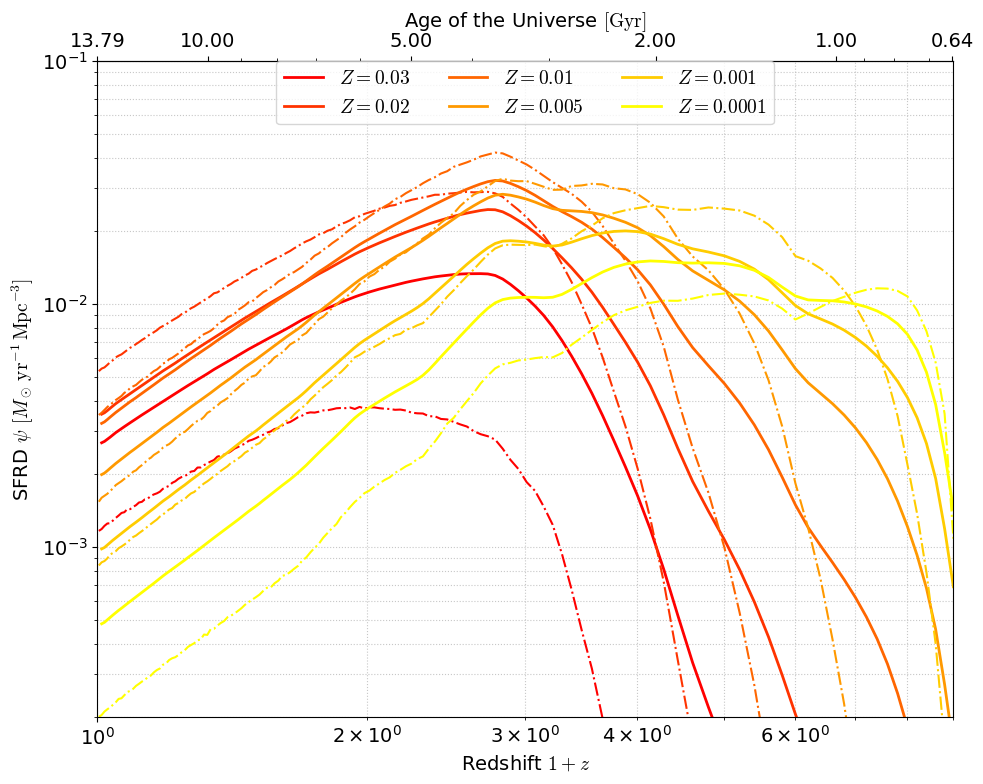

In [185]:
keys = ['MZ19'] #['LZ19', 'HZ19', 'MZ19', 'LZ21', 'HZ21']
for key in keys:
    df = pd.read_csv(f'{key}_SFRD_allbins.txt')
    labels = ['$Z = 0.03$', '$Z=0.02$', '$Z=0.01$','$Z=0.005$','$Z=0.001$', '$Z=0.0001$']
    cmap = plt.get_cmap('autumn')
    colors = cmap(np.linspace(0,1,len(labels)))

    redshift = df['redshift']
    print(redshift)
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10,8)) # Increased figure size slightly for better label spacing

    global_data = np.zeros_like(redshift)
    for i, label in enumerate(labels):
        data = df[f'{i}']
        ax.plot(1 + redshift, IMF_conv* data, label=label, color=colors[i], linewidth=2)
        ax.plot(1+jnp.flip(redshift_global), IMF_conv * sfrd_z_Z[:,-(i+1)], color=colors[i], ls='-.')
        # ax.plot(1+z_eval, IMF_conv* psi[:,i], ls='-.')
        global_data += data

    ax.grid(True, which='both', linestyle=':', alpha=0.7) # Added more grid options


    ax.set_xlim([1, 9]) # Corresponds to z from 0 to 10
    ax.set_xscale('log')
    # ax.set_yscale('log') # Uncomment if you want log scale on y-axis
    ax.grid(which='both', linestyle=':', alpha=0.7)
    ax.set_xlabel(r'Redshift $1+z$')
    ax.set_ylabel(r'SFRD $\psi$ $[M_\odot \, \mathrm{yr}^{-1} \, \mathrm{Mpc}^{-3}]$') # Fixed unit formatting

    # --- Add the secondary x-axis for Age of the Universe ---
    secax_x = ax.secondary_xaxis('top', functions=(one_plus_z_to_age, age_to_one_plus_z))
    secax_x.set_xlabel(r'Age of the Universe $[\rm{Gyr}]$')

    # Optional: Customize tick formatting for the age axis
    from matplotlib.ticker import FuncFormatter, StrMethodFormatter
    # Example: Format to one or two decimal places if desired
    # secax_x.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}'))
    secax_x.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}')) # e.g. 0.47 Gyr, 13.78 Gyr

    # You might want to suggest tick locations for the age axis too,
    # especially because the primary axis is log-scaled.
    # Age at 1+z=1 (z=0) is ~13.78 Gyr
    # Age at 1+z=11 (z=10) is ~0.47 Gyr
    # Suggested age ticks (in Gyr)
    # Let's try to get some ticks that are reasonably spaced in the age domain
    age_tick_values_gyr = np.array([1, 2, 5, 10, cosmo.age(0).to(u.Gyr).value])
    # Filter ticks to be within the actual age range of the plot
    min_age_on_plot = one_plus_z_to_age(ax.get_xlim()[1]) # Age at max 1+z (min age)
    max_age_on_plot = one_plus_z_to_age(ax.get_xlim()[0]) # Age at min 1+z (max age)

    filtered_age_ticks = age_tick_values_gyr[(age_tick_values_gyr >= min_age_on_plot*0.95) & (age_tick_values_gyr <= max_age_on_plot*1.05)] # Add small margin
    # Ensure the boundaries are present if they are not too close to other ticks
    if not np.any(np.isclose(filtered_age_ticks, min_age_on_plot)):
        filtered_age_ticks = np.sort(np.append(filtered_age_ticks, min_age_on_plot))
    if not np.any(np.isclose(filtered_age_ticks, max_age_on_plot)):
         filtered_age_ticks = np.sort(np.append(filtered_age_ticks, max_age_on_plot))
    # Remove duplicates that might arise from np.isclose logic
    filtered_age_ticks = np.unique(np.round(filtered_age_ticks, 2))



    if len(filtered_age_ticks) > 1:
        secax_x.set_xticks(filtered_age_ticks)
    else: # Fallback if filtering is too aggressive
        secax_x.set_xticks(np.round([min_age_on_plot, max_age_on_plot],2))

    plt.ylim([0.0002, 0.1])
    plt.yscale('log')
    plt.legend(loc='upper center', ncol=3, borderaxespad=0.)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    # plt.savefig(f"{key}_vs_redshift_and_age_for_different_metallicities.pdf")
    plt.show()

np.float64(0.1334161162620927)

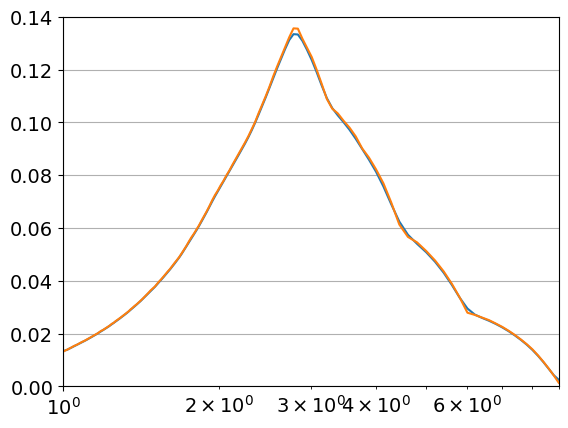

In [138]:
plt.plot(1+redshift, global_data)
plt.plot(1+redshift_global, jnp.sum(sfrd_z_Z,axis=1))
plt.xscale("log")
plt.xlim([1,9])
plt.ylim([0.0, 0.14])
plt.grid()
np.max(global_data)

In [36]:
image,redshift,delt = get_plot_data(mod,0.,10)
np.shape(image), np.shape(redshift)

((150, 200), (150,))

C:\Users\coenr\AppData\Local\Temp\ipykernel_15732\2481899748.py:29: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_data = np.array([ quad(integrand, z_range[i], z_range[-1], args=(interp_SFRD,))[0] for i in range(len(z_range))])
C:\Users\coenr\AppData\Local\Temp\ipykernel_15732\2481899748.py:33: RuntimeWarning: divide by zero encountered in log10
  ax.plot(z_range, np.log10(0.62/1.06*0.59*integral_MnD), label='MnD to Chabrier, R=0.41')
C:\Users\coenr\AppData\Local\Temp\ipykernel_15732\2481899748.py:34: RuntimeWarning: divide by zero encountered in log10
  ax.fill_between(z

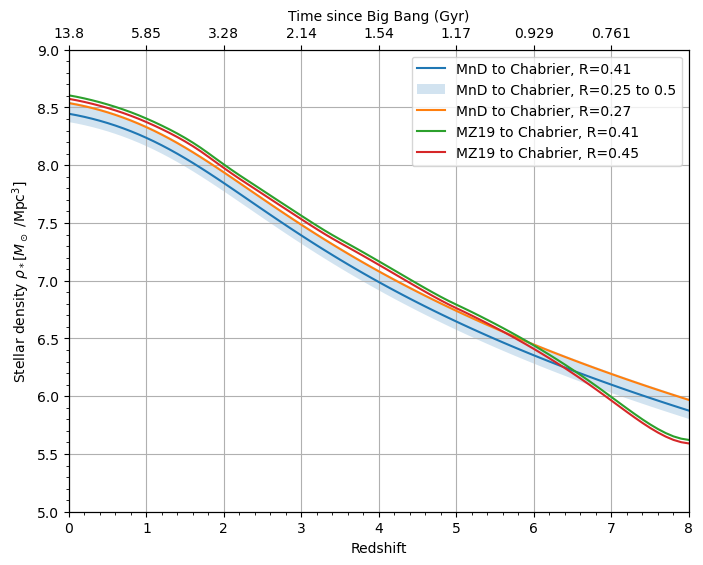

C:\Users\coenr\AppData\Local\Temp\ipykernel_15732\2481899748.py:63: RuntimeWarning: invalid value encountered in divide
  plt.plot(z_range, integral_data / (0.62*integral_MnD))


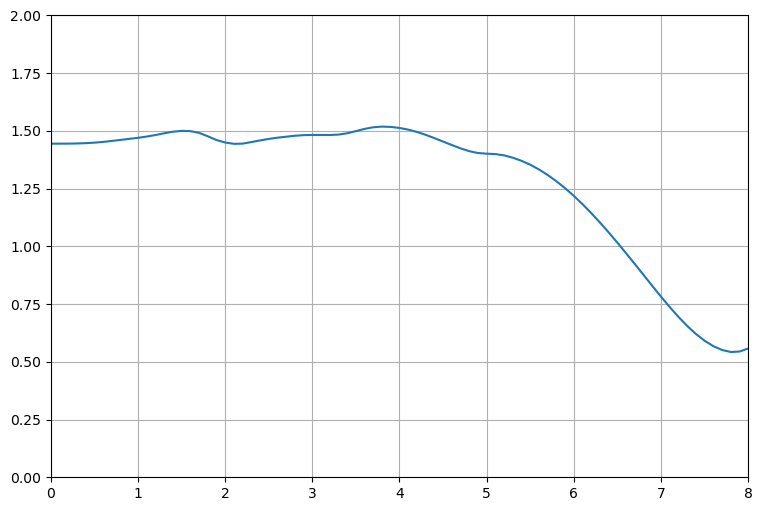

In [5]:
from scipy.integrate import quad
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from astropy.cosmology import z_at_value
from scipy.interpolate import InterpolatedUnivariateSpline as IUSpline


def density_plotting(z_range, cosmo_params, alpha, SFRD_data, plot=True):
    H0, OM0 = cosmo_params    
    redshift, SFRD_z = SFRD_data
    SFR_interp = IUSpline(np.flip(redshift), np.flip(SFRD_z), k=3)
    
    def interp_SFRD(z):
        if z > max(redshift):
            return SFR_interp(max(redshift))
        else:
            return SFR_interp(z)
        
    def phi_MnD(z):
        return 0.015 * (1+z)**(2.7) / (1 + ((z+1)/2.9)**5.6)
    
    def integrand(z, func): # this takes into account a shift in coordinates from t to z'
        tH = 1 / (H0 / ( 3.08567758 * 10**19)) / (365*24*3600) # in years
        E = np.sqrt(OM0*(1+z)**3 + 1 - OM0)
        SFRD = func(z)
        return tH / (E*(1+z)) * SFRD

    integral_MnD = np.array([ quad(integrand, z_range[i], z_range[-1], args=(phi_MnD,))[0] for i in range(len(z_range))])
    integral_data = np.array([ quad(integrand, z_range[i], z_range[-1], args=(interp_SFRD,))[0] for i in range(len(z_range))])
 
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111)
    ax.plot(z_range, np.log10(0.62/1.06*0.59*integral_MnD), label='MnD to Chabrier, R=0.41')
    ax.fill_between(z_range, np.log10(0.62/1.06*0.5*integral_MnD), np.log10(0.62/1.06*0.75*integral_MnD), alpha=0.2, label='MnD to Chabrier, R=0.25 to 0.5')
    ax.plot(z_range, np.log10(0.62/1.06*0.73*integral_MnD), label='MnD to Chabrier, R=0.27')
        
    ax.plot(z_range, np.log10(1/1.06*0.59*integral_data), label='MZ19 to Chabrier, R=0.41')
    ax.plot(z_range, np.log10(1/1.06*0.55*integral_data), label='MZ19 to Chabrier, R=0.45')
    plt.legend()
    #ax.plot(z_arr, SFR_total * cosmo_factor(z_arr), label='Original SFR Data')
    ages = (cosmo.age(0) - cosmo.lookback_time(np.arange(0.0001, 8, 1))).to(u.yr)
    ageticks = [z_at_value(cosmo.age, age) for age in ages]
    ax2 = ax.twiny()
    ax2.set_xticks(ageticks)
    ax2.set_xticklabels(['{:.3g}'.format(age) for age in ages.to(u.Gyr).value])
    ax.set_xlim(0, 8)
    ax2.set_xlim(0,8)
    ax.set_ylim([5,9])
    #ax.set_ylim([2e5, 8e8])
    ax2.set_xlabel('Time since Big Bang (Gyr)')
    ax.set_xlabel('Redshift')
    ax.set_ylabel(r'Stellar density $\rho_* [M_\odot$ /Mpc$^3$]')
    #ax.set_yscale('log')
    ax.minorticks_on()
    ax.grid(True)#, which='both')
    
    if plot == True:
        plt.show()
    if plot == False:
        plt.close()
    
    plt.figure(figsize=(9,6))
    plt.plot(z_range, integral_data / (0.62*integral_MnD))
    plt.xlim(0,8)
    plt.ylim(0,2)
    plt.grid(True)
    if plot == True:
        plt.show()
    if plot == False:
        plt.close()
    
    #print(1/1.06*0.55*integral_data[3])
    return 1/1.06*0.55*integral_data, 0.62/1.06*0.55*integral_MnD


alpha = 0.59
cosmo_params = [67.66, 0.30966] # planck18
z_range = np.linspace(0,1000, 10**4)
SFRD_data = [redshift, SFRD_z]
stellar_density = density_plotting(z_range, cosmo_params, alpha, SFRD_data)

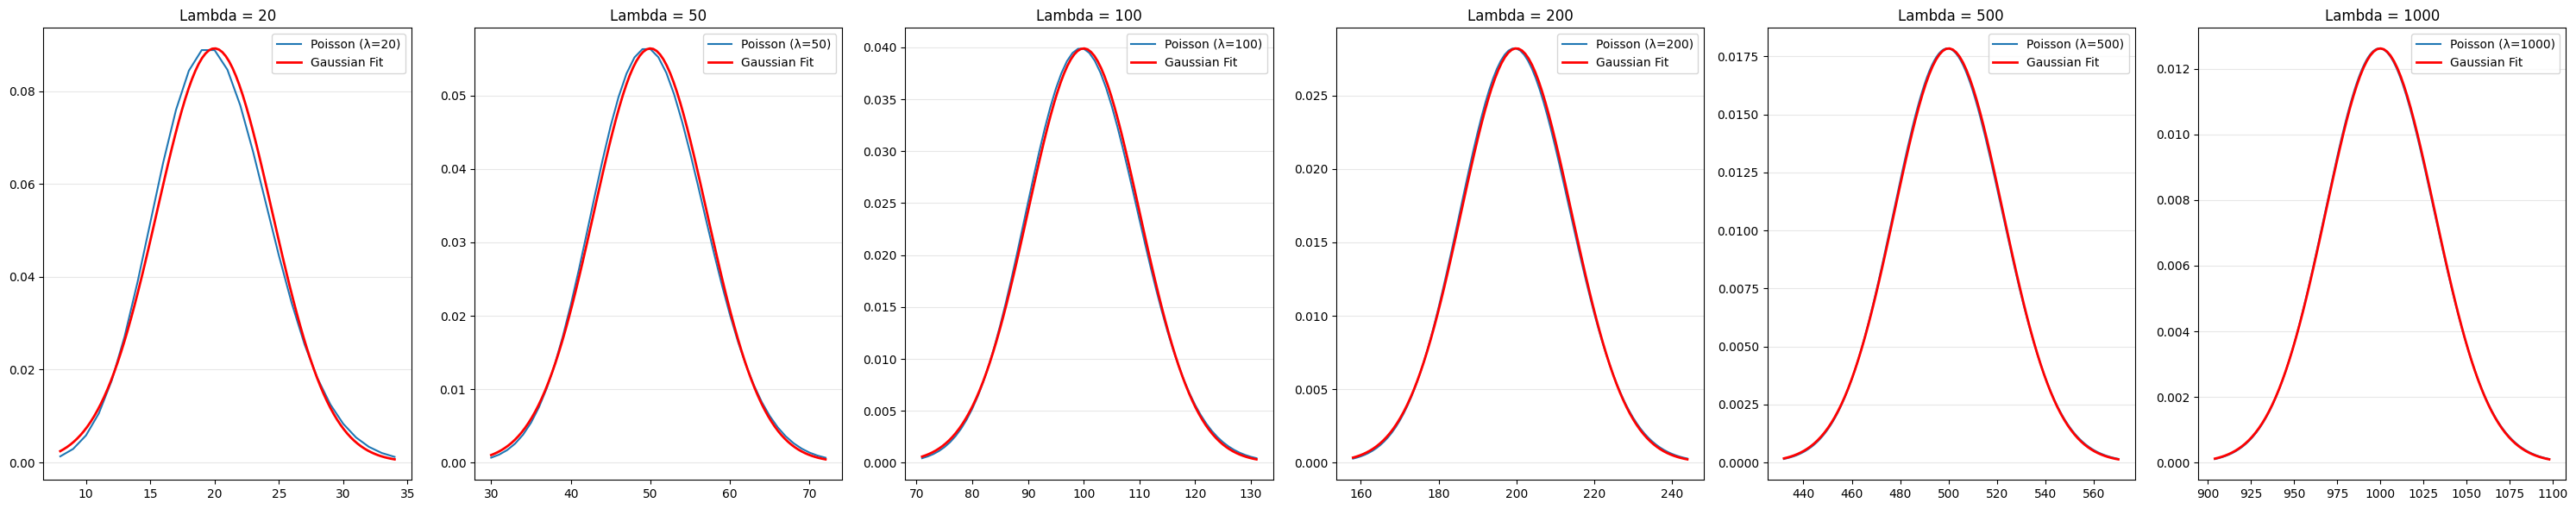

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

def visualize_convergence(lambdas):
    plt.figure(figsize=(5*len(lambdas), 6))
    
    for i, lam in enumerate(lambdas, 1):
        plt.subplot(1, len(lambdas), i)
        
        # Define the range of x values (around the mean)
        x = np.arange(poisson.ppf(0.001, lam), poisson.ppf(0.999, lam))
        
        # Poisson PMF (Probability Mass Function)
        y_poisson = poisson.pmf(x, lam)
        plt.plot(x, y_poisson,label=f'Poisson (λ={lam})', color='tab:blue')
        
        # Gaussian PDF (Probability Density Function) 
        # using Mean = lam and Std Dev = sqrt(lam)
        x_continuous = np.linspace(x.min(), x.max(), 100)
        y_gaussian = norm.pdf(x_continuous, loc=lam, scale=np.sqrt(lam))
        plt.plot(x_continuous, y_gaussian, 'r-', lw=2, label='Gaussian Fit')
        
        plt.title(f'Lambda = {lam}')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualize the shift from a small lambda to a large one
visualize_convergence([20, 50, 100, 200, 500, 1000])
